In [1]:
import sys
sys.path.append('..')

import pandas as pd
import plotly.express as px
from entsoe import EntsoePandasClient
from dotenv import load_dotenv
import os
from datetime import datetime, timedelta

load_dotenv(dotenv_path=r"C:\Users\IvaRichterová\Desktop\entsoe-dashboard\.env")
TOKEN = os.getenv("ENTSOE_TOKEN")

client = EntsoePandasClient(api_key=TOKEN)

konec   = pd.Timestamp.now(tz="UTC").floor("h")
zacatek = konec - pd.Timedelta(days=30)

print("✓ Vše připraveno")

✓ Vše připraveno


In [2]:
cache_slozka = r"C:\Users\IvaRichterová\Desktop\entsoe-dashboard\data\cache"
soubor_vyroba_parquet = os.path.join(cache_slozka, "vyroba_cz.parquet")
soubor_vyroba_csv = os.path.join(cache_slozka, "vyroba_cz.csv")

if os.path.exists(soubor_vyroba_parquet):
    stari = datetime.now() - datetime.fromtimestamp(os.path.getmtime(soubor_vyroba_parquet))
    if stari < timedelta(hours=24):
        print("✓ Výroba: načteno z cache")
        vyroba = pd.read_parquet(soubor_vyroba_parquet)
        vyroba.index = vyroba.index.tz_convert("Europe/Prague")
    else:
        vyroba = None
else:
    vyroba = None

if vyroba is None:
    print("Stahuji výrobu z API...")
    vyroba = client.query_generation(
        country_code="10YCZ-CEPS-----N",
        start=zacatek,
        end=konec,
    )
    vyroba = vyroba.tz_convert("Europe/Prague")
    vyroba.to_parquet(soubor_vyroba_parquet)
    vyroba.to_csv(soubor_vyroba_csv)
    print(f"✓ Výroba stažena: {vyroba.shape[0]} řádků, {vyroba.shape[1]} zdrojů")

✓ Výroba: načteno z cache


In [3]:
print("=== Dostupné zdroje výroby ===")
for sloupec in vyroba.columns:
    print(f"  {sloupec}")

=== Dostupné zdroje výroby ===
  ('Biomass', 'Actual Aggregated')
  ('Fossil Brown coal/Lignite', 'Actual Aggregated')
  ('Fossil Coal-derived gas', 'Actual Aggregated')
  ('Fossil Gas', 'Actual Aggregated')
  ('Fossil Hard coal', 'Actual Aggregated')
  ('Fossil Oil', 'Actual Aggregated')
  ('Hydro Pumped Storage', 'Actual Aggregated')
  ('Hydro Pumped Storage', 'Actual Consumption')
  ('Hydro Run-of-river and poundage', 'Actual Aggregated')
  ('Hydro Water Reservoir', 'Actual Aggregated')
  ('Nuclear', 'Actual Aggregated')
  ('Other', 'Actual Aggregated')
  ('Other renewable', 'Actual Aggregated')
  ('Solar', 'Actual Aggregated')
  ('Waste', 'Actual Aggregated')
  ('Wind Onshore', 'Actual Aggregated')


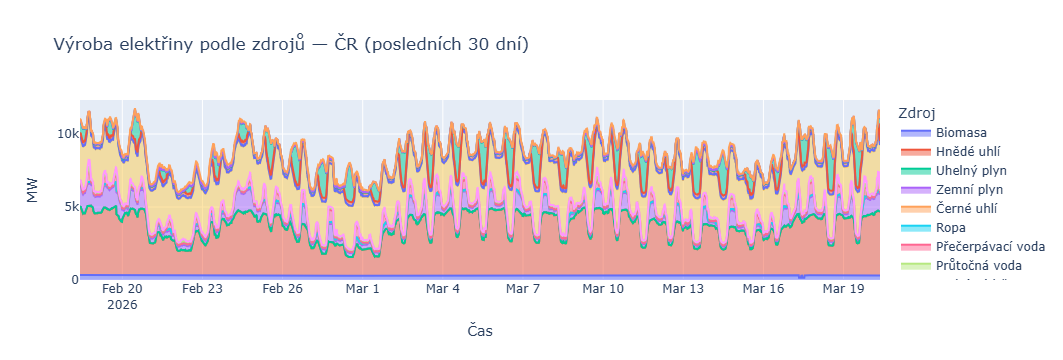

In [4]:
# Vybereme jen sloupce "Actual Aggregated" - tedy skutečnou výrobu
# Pumped Storage Consumption vynecháme - to je spotřeba, ne výroba
vyroba_clean = vyroba.xs("Actual Aggregated", axis=1, level=1)

# Přejmenujeme zdroje do češtiny
nazvy = {
    "Biomass": "Biomasa",
    "Fossil Brown coal/Lignite": "Hnědé uhlí",
    "Fossil Coal-derived gas": "Uhelný plyn",
    "Fossil Gas": "Zemní plyn",
    "Fossil Hard coal": "Černé uhlí",
    "Fossil Oil": "Ropa",
    "Hydro Pumped Storage": "Přečerpávací voda",
    "Hydro Run-of-river and poundage": "Průtočná voda",
    "Hydro Water Reservoir": "Vodní nádrž",
    "Nuclear": "Jádro",
    "Other": "Ostatní",
    "Other renewable": "Ostatní OZE",
    "Solar": "Solár",
    "Waste": "Odpad",
    "Wind Onshore": "Vítr",
}

vyroba_clean = vyroba_clean.rename(columns=nazvy)

# Stacked area chart
fig = px.area(
    vyroba_clean,
    title="Výroba elektřiny podle zdrojů — ČR (posledních 30 dní)",
    labels={"value": "MW", "index": "Čas", "variable": "Zdroj"},
)

fig.show()

=== Jádro — statistiky ===
  Průměr:  2967 MW
  Minimum: 2934 MW
  Maximum: 2982 MW


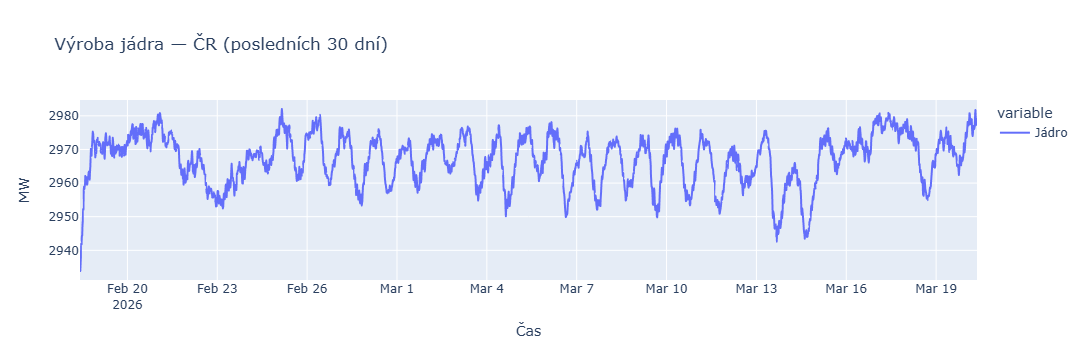

In [5]:
# Jádro samostatně
print("=== Jádro — statistiky ===")
print(f"  Průměr:  {vyroba_clean['Jádro'].mean():.0f} MW")
print(f"  Minimum: {vyroba_clean['Jádro'].min():.0f} MW")
print(f"  Maximum: {vyroba_clean['Jádro'].max():.0f} MW")

# Graf jen jádra
fig = px.line(
    vyroba_clean["Jádro"],
    title="Výroba jádra — ČR (posledních 30 dní)",
    labels={"value": "MW", "index": "Čas"},
)
fig.show()

=== Solár — statistiky ===
  Průměr:  589 MW
  Minimum: 0 MW
  Maximum: 3083 MW


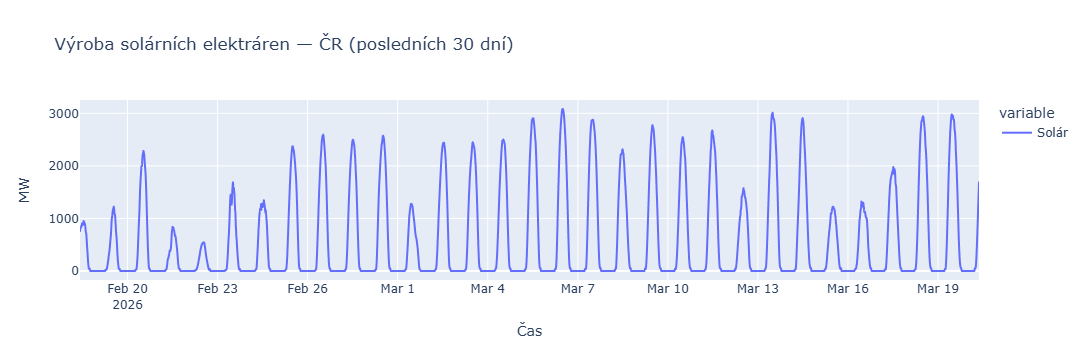

In [6]:
print("=== Solár — statistiky ===")
print(f"  Průměr:  {vyroba_clean['Solár'].mean():.0f} MW")
print(f"  Minimum: {vyroba_clean['Solár'].min():.0f} MW")
print(f"  Maximum: {vyroba_clean['Solár'].max():.0f} MW")

fig = px.line(
    vyroba_clean["Solár"],
    title="Výroba solárních elektráren — ČR (posledních 30 dní)",
    labels={"value": "MW", "index": "Čas"},
)
fig.show()

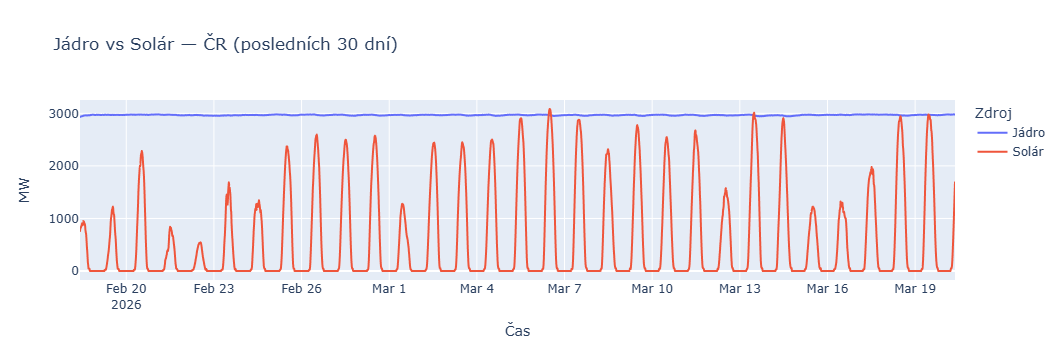

In [7]:
fig = px.line(
    vyroba_clean[["Jádro", "Solár"]],
    title="Jádro vs Solár — ČR (posledních 30 dní)",
    labels={"value": "MW", "index": "Čas", "variable": "Zdroj"},
)
fig.show()

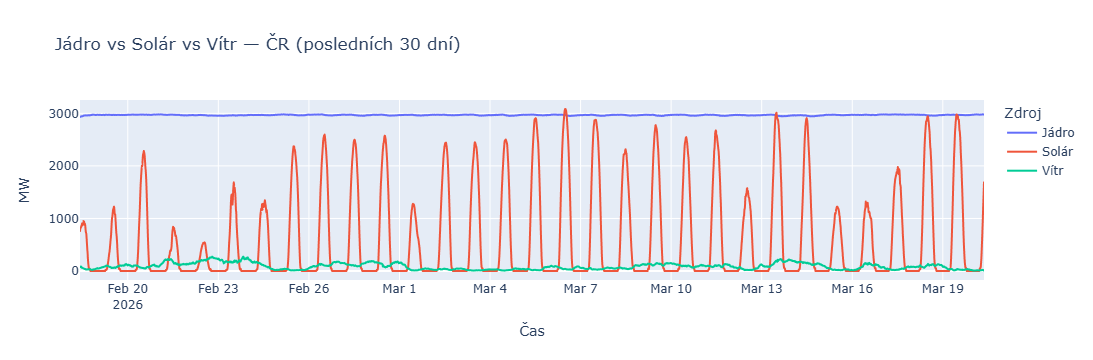

In [8]:
fig = px.line(
    vyroba_clean[["Jádro", "Solár", "Vítr"]],
    title="Jádro vs Solár vs Vítr — ČR (posledních 30 dní)",
    labels={"value": "MW", "index": "Čas", "variable": "Zdroj"},
)
fig.show()

In [9]:
print("=== Vítr — statistiky ===")
print(f"  Průměr:  {vyroba_clean['Vítr'].mean():.0f} MW")
print(f"  Minimum: {vyroba_clean['Vítr'].min():.0f} MW")
print(f"  Maximum: {vyroba_clean['Vítr'].max():.0f} MW")


=== Vítr — statistiky ===
  Průměr:  87 MW
  Minimum: 8 MW
  Maximum: 273 MW


=== Podíl OZE ===
  Průměrný podíl OZE: 13.5 %
  Maximum:            30.1 %
  Minimum:            6.6 %


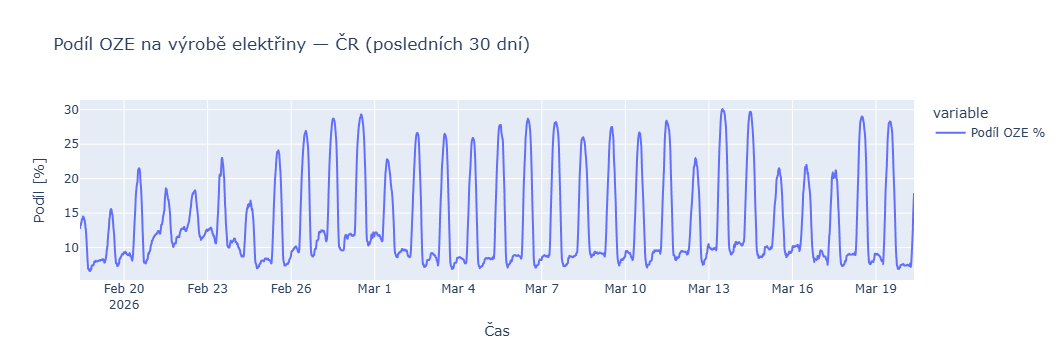

In [10]:
# OZE = solár + vítr + biomasa + průtočná voda + ostatní OZE
vyroba_clean["OZE celkem"] = (
    vyroba_clean["Solár"] +
    vyroba_clean["Vítr"] +
    vyroba_clean["Biomasa"] +
    vyroba_clean["Průtočná voda"] +
    vyroba_clean["Ostatní OZE"]
)

# Celková výroba
vyroba_clean["Celkem"] = vyroba_clean.sum(axis=1)

# Podíl OZE v %
vyroba_clean["Podíl OZE %"] = (vyroba_clean["OZE celkem"] / vyroba_clean["Celkem"] * 100).round(1)

print("=== Podíl OZE ===")
print(f"  Průměrný podíl OZE: {vyroba_clean['Podíl OZE %'].mean():.1f} %")
print(f"  Maximum:            {vyroba_clean['Podíl OZE %'].max():.1f} %")
print(f"  Minimum:            {vyroba_clean['Podíl OZE %'].min():.1f} %")

fig = px.line(
    vyroba_clean["Podíl OZE %"],
    title="Podíl OZE na výrobě elektřiny — ČR (posledních 30 dní)",
    labels={"value": "Podíl [%]", "index": "Čas"},
)
fig.show()

In [11]:
import os

export_slozka = r"C:\Users\IvaRichterová\Desktop\entsoe-dashboard\exports"
os.makedirs(export_slozka, exist_ok=True)

# Stacked area chart
fig.write_image(os.path.join(export_slozka, "03_vyroba_zdroje.png"), width=1200, height=600)
fig.write_html(os.path.join(export_slozka, "03_vyroba_zdroje.html"))

print("✓ Exporty notebooku 03 uloženy")

✓ Exporty notebooku 03 uloženy
